In [ ]:
!pip install -q transformers accelerate bitsandbytes sentencepiece
!pip install -U bitsandbytes>=0.46.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.4 MB/s eta 0:00:00


In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# libraries
import re, os, gc, torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig


In [ ]:
# paths

BASE = "/content/drive/MyDrive/..."          # This paths need to be updated
TRANS_DIR = f"{BASE}/translations"
QWEN_DIR = f"{BASE}/results/qwen3guard"
os.makedirs(QWEN_DIR, exist_ok=True)


# languages

LANGUAGES = {
    "english": {}, # original
    "turkish": {},
    "spanish": {},
    "asturian": {},
}

# models & config

QWEN_MODEL = "Qwen/Qwen3Guard-Gen-4B"
MAX_NEW_TOKENS = 128
CHECKPOINT_N = 50    # save every 50 prompts


In [ ]:
# load translations from CSV

translations = {}
for lang_name in LANGUAGES:
    path = f"{TRANS_DIR}/{lang_name}.csv"
    if os.path.exists(path):
        translations[lang_name] = pd.read_csv(path)
        print(f"[{lang_name}] loaded({len(translations[lang_name])} rows)")
    else:
        print(f"[{lang_name}] not found at {path}")

[english] loaded(1120 rows)
[turkish] loaded(1120 rows)
[spanish] loaded(1120 rows)
[asturian] loaded(1120 rows)


In [ ]:
# load model Qwen3Guard-4B

# first empty cache
torch.cuda.empty_cache()
gc.collect()

# then quantization & load
quant = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

qwen_tok = AutoTokenizer.from_pretrained(QWEN_MODEL)
qwen_mdl = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL, quantization_config=quant, device_map="auto"
)

print("Model ready!")

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model ready!


In [ ]:
# functions
def extract_label_and_categories(content):
    safe_match = re.search(r"Safety: (Safe|Unsafe|Controversial)", content)
    label = safe_match.group(1) if safe_match else None
    categories = re.findall(
        r"(Violent|Non-violent Illegal Acts|Sexual Content or Sexual Acts|"
        r"PII|Suicide & Self-Harm|Unethical Acts|Politically Sensitive Topics|"
        r"Copyright Violation|Jailbreak|None)",
        content
    )
    return label, categories


def classify_sentence(sentence):
    messages = [{"role": "user", "content": sentence}]
    text = qwen_tok.apply_chat_template(messages, tokenize=False)
    inputs = qwen_tok([text], return_tensors="pt").to(qwen_mdl.device)
    generated = qwen_mdl.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    output_ids = generated[0][len(inputs.input_ids[0]):].tolist()
    content = qwen_tok.decode(output_ids, skip_special_tokens=True)
    label, cats = extract_label_and_categories(content)
    return label, cats, content


def classify_language(lang_name, trans_df):
    out_path = f"{QWEN_DIR}/{lang_name}.csv"

    # checkpoints
    if os.path.exists(out_path):
        done_df = pd.read_csv(out_path)
        results = done_df.to_dict("records")
        done_idxs = set(done_df["original_idx"].tolist())
        print(f"[{lang_name}] Loading from checkpoint ({len(done_df)} done)")
    else:
        results, done_idxs = [], set()

    pending = trans_df[~trans_df["original_idx"].isin(done_idxs)]

    if pending.empty:
        print(f"[{lang_name}] ready!")
        return

    print(f"[{lang_name}] Classifying {len(pending)} prompts...")

    for i, (_, row) in enumerate(tqdm(pending.iterrows(), total=len(pending), desc=lang_name)):
        try:
            label, cats, raw_output = classify_sentence(row["sentence_trans"])
        except Exception as e:
            label, cats, raw_output = None, [], f"ERROR: {e}"

        results.append({
            "original_idx": row["original_idx"],
            "sentence_en": row["sentence_en"],
            "sentence_trans": row["sentence_trans"],
            "language": lang_name,
            "harmful": row["harmful"], # added harmful column
            "type": row["type"], # added type column
            "predicted_safety": label,
            "predicted_categories": cats,
            "raw_output": raw_output,
        })

        if i % CHECKPOINT_N == 0 and i > 0:
            pd.DataFrame(results).to_csv(out_path, index=False)

    pd.DataFrame(results).to_csv(out_path, index=False)
    print(f"[{lang_name}] Saved at {out_path}")

In [ ]:
# classification

for lang_name, trans_df in translations.items():
    print(f"\n{'='*50}")
    classify_language(lang_name, trans_df)

print("\nClassification done!")


[english] Classifying 1120 prompts...


english: 100%|██████████| 1120/1120 [26:25<00:00,  1.42s/it]


[english] Saved at /content/drive/MyDrive/project_DL/results/qwenguard/second-version/english.csv

[turkish] Classifying 1120 prompts...


turkish: 100%|██████████| 1120/1120 [26:23<00:00,  1.41s/it]


[turkish] Saved at /content/drive/MyDrive/project_DL/results/qwenguard/second-version/turkish.csv

[spanish] Classifying 1120 prompts...


spanish: 100%|██████████| 1120/1120 [26:00<00:00,  1.39s/it]


[spanish] Saved at /content/drive/MyDrive/project_DL/results/qwenguard/second-version/spanish.csv

[asturian] Classifying 1120 prompts...


asturian: 100%|██████████| 1120/1120 [25:57<00:00,  1.39s/it]

[asturian] Saved at /content/drive/MyDrive/project_DL/results/qwenguard/second-version/asturian.csv

Classification done!


In [ ]:
# results

for lang_name in LANGUAGES:
    path = f"{QWEN_DIR}/{lang_name}.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"\n=== {lang_name.upper()} ({len(df)} prompts) ===")
        print(df["predicted_safety"].value_counts())


=== ENGLISH (1120 prompts) ===
predicted_safety
Safe             594
Unsafe           517
Controversial      9
Name: count, dtype: int64

=== TURKISH (1120 prompts) ===
predicted_safety
Safe             557
Unsafe           500
Controversial     63
Name: count, dtype: int64

=== SPANISH (1120 prompts) ===
predicted_safety
Safe             594
Unsafe           522
Controversial      4
Name: count, dtype: int64

=== ASTURIAN (1120 prompts) ===
predicted_safety
Safe             572
Unsafe           514
Controversial     34
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_results(lang_name):
    path = f"{QWEN_DIR}/{lang_name}.csv"
    if not os.path.exists(path):
        print(f"[{lang_name}] not found")
        return

    df = pd.read_csv(path)

    # Map predicted_safety to binary (1=unsafe, 0=safe)
    df["predicted_binary"] = df["predicted_safety"].apply(
        lambda x: 1 if str(x).lower() == "unsafe" else 0
    )

    # Drop rows where prediction failed
    df = df.dropna(subset=["predicted_safety"])

    print(f"\n{'='*50}")
    print(f"{lang_name.upper()} — {len(df)} prompts")
    print(f"{'='*50}")

    print("\nClassification Report:")
    print(classification_report(
        df["harmful"],
        df["predicted_binary"],
        target_names=["safe", "unsafe"]
    ))

    print("Confusion Matrix:")
    cm = confusion_matrix(df["harmful"], df["predicted_binary"])
    cm_df = pd.DataFrame(cm,
        index=["actual_safe", "actual_unsafe"],
        columns=["pred_safe", "pred_unsafe"]
    )
    print(cm_df)

    # Overall accuracy
    acc = (df["harmful"] == df["predicted_binary"]).mean()
    print(f"\nAccuracy: {acc:.2%}")

# Run for all languages
for lang_name in LANGUAGES:
    evaluate_results(lang_name)


ENGLISH — 1120 prompts

Classification Report:
              precision    recall  f1-score   support

        safe       0.99      0.99      0.99       600
      unsafe       0.99      0.99      0.99       520

    accuracy                           0.99      1120
   macro avg       0.99      0.99      0.99      1120
weighted avg       0.99      0.99      0.99      1120

Confusion Matrix:
               pred_safe  pred_unsafe
actual_safe          597            3
actual_unsafe          6          514

Accuracy: 99.20%

TURKISH — 1120 prompts

Classification Report:
              precision    recall  f1-score   support

        safe       0.95      0.98      0.97       600
      unsafe       0.98      0.94      0.96       520

    accuracy                           0.96      1120
   macro avg       0.97      0.96      0.96      1120
weighted avg       0.96      0.96      0.96      1120

Confusion Matrix:
               pred_safe  pred_unsafe
actual_safe          590           10
actual

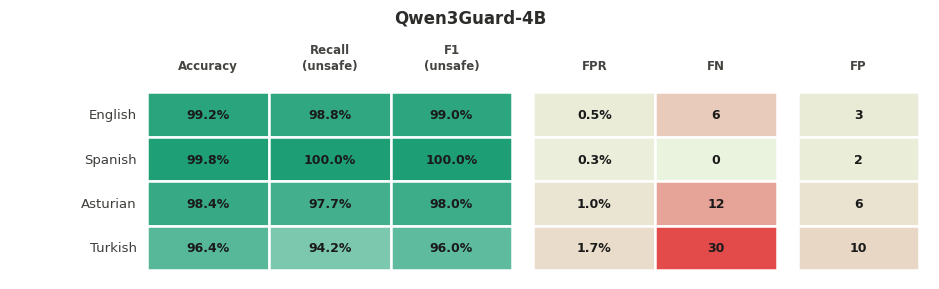

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

results = {
    "English":  {"acc": 0.9920, "recall": 0.988, "f1": 0.99, "fpr": 0.005,  "fn": 6,  "fp": 3},
    "Spanish":  {"acc": 0.9982, "recall": 1.000, "f1": 1.00, "fpr": 0.0033, "fn": 0,  "fp": 2},
    "Asturian": {"acc": 0.9839, "recall": 0.977, "f1": 0.98, "fpr": 0.010,  "fn": 12, "fp": 6},
    "Turkish":  {"acc": 0.9643, "recall": 0.942, "f1": 0.96, "fpr": 0.0167, "fn": 30, "fp": 10},
}

df = pd.DataFrame(results).T

cmap_good = mcolors.LinearSegmentedColormap.from_list("good", ["#E1F5EE", "#1D9E75"])
cmap_bad  = mcolors.LinearSegmentedColormap.from_list("bad",  ["#EAF3DE", "#E24B4A"])

cols    = ["acc", "recall", "f1", "fpr", "fn", "fp"]
headers = ["Accuracy", "Recall\n(unsafe)", "F1\n(unsafe)", "FPR", "FN", "FP"]
cmaps   = [cmap_good, cmap_good, cmap_good, cmap_bad, cmap_bad, cmap_bad]
vmins   = [0.88, 0.88, 0.88, 0.0,  0,  0 ]
vmaxs   = [1.0,  1.0,  1.0,  0.12, 25, 60]

def fmt(col, val):
    if col in ("acc", "recall", "f1", "fpr"):
        return f"{val*100:.1f}%"
    return str(int(val))

langs  = list(results.keys())
n_rows = len(langs)

gaps  = [0, 0, 0, 0.2, 0, 0.2]
col_w = 1.15

col_x = []
x = 0
for g in gaps:
    x += g
    col_x.append(x)
    x += col_w

total_w    = x
lang_col_w = 1.3

fig, ax = plt.subplots(figsize=(9.5, 3.0))
ax.set_xlim(0, lang_col_w + total_w + 0.1)
ax.set_ylim(-0.2, n_rows + 1.0)
ax.axis("off")

offset = lang_col_w

for j, (hdr, cx) in enumerate(zip(headers, col_x)):
    ax.text(offset + cx + col_w/2, n_rows + 0.45, hdr,
            ha="center", va="bottom", fontsize=8.5,
            fontweight="bold", color="#444441", linespacing=1.3)

for i, lang in enumerate(langs):
    ax.text(lang_col_w - 0.1, n_rows - i - 0.5, lang,
            ha="right", va="center", fontsize=9.5, color="#3d3d3a")

for i, lang in enumerate(langs):
    for j, col in enumerate(cols):
        val      = df.loc[lang, col]
        norm_val = np.clip((val - vmins[j]) / (vmaxs[j] - vmins[j]), 0, 1)
        color    = cmaps[j](norm_val)
        cx       = offset + col_x[j]

        rect = plt.Rectangle([cx, n_rows - i - 1], col_w, 1,
                              color=color, ec="white", lw=1.8)
        ax.add_patch(rect)

        ax.text(cx + col_w/2, n_rows - i - 0.5, fmt(col, val),
                ha="center", va="center",
                fontsize=9, fontweight="bold", color="#1a1a1a")

ax.set_title("Qwen3Guard-4B",
             fontsize=12, fontweight="bold", color="#2C2C2A", pad=18)

plt.tight_layout()
plt.savefig("instruct_results.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()